# 04 · Switchback experiments, CUPED & variance reduction — a hands-on lab

A **practical** companion to the primer (`paper-library/papers/switchback-and-variance-reduction.md`).
We re-implement the DoorDash switchback simulator (Pankratev 2026) and *learn by doing*: what a
switchback is, why naive analysis is hard, and how the variance-reduction family
**Raw → CUPED → CUPAC → DML-DR** buys power — plus the two non-obvious lessons (target *macro* shocks,
and the efficiency-vs-robustness trap).

This notebook is **self-contained** — it does not use the Vega engine; the simulator *is* the
"example and sim from the paper." Like Vega, we author the data-generating process, so we have
**ground truth** (the true effect τ and the latent shocks) to validate against.

**Roadmap:** (1) what/why · (2) the simulator · (3) the four estimators · (4) the headline table ·
(5) power & the structural floor · (6) the challenges (cluster imbalance, autocorrelation, carryover
Type-S) · (7) recommendations.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold

# house style (same palette as the other Vega notebooks/study guides)
import nbtools; nbtools.set_style()
RAW, CUPED, CUPAC, DML = "#8a93a6", "#6ea8fe", "#3fb68b", "#e08c4f"   # estimator colours (poster scheme)
COL = {"Raw": RAW, "CUPED": CUPED, "CUPAC": CUPAC, "DML-DR": DML}

## 1. What is a switchback, and why?

On a marketplace the unit of interest is a **cross-sectional entity** observed over time — a delivery
zone, a city. A user-level A/B test there is **biased by interference**: a dispatch/pricing change
moves *shared* supply (couriers), so a treated user's outcome depends on how many *others* are treated
(SUTVA fails). Randomizing whole markets fixes that but gives sample size ≈ 2.

A **switchback** holds the market fixed and **randomizes the treatment over time** — on/off across
successive periods, so the same market is its own control. The unit of randomization is a
**cell = cluster × period**. You buy immunity to *cross-sectional* interference at the price of new
*temporal* problems: **carryover** (a treatment persists after switch-off), **autocorrelation**, and a
finite, lumpy set of cells. (Bojinov–Simchi-Levi–Zhao 2021; used at DoorDash, Lyft, Uber.)

## 2. The data-generating process

A cell's outcome is a sum of **multi-level shocks** + treatment + SUTVA violations (Pankratev 2026):

$$Y_{i,cl,t} = \underbrace{\mu + \alpha_{cl} + \gamma_t + \delta_{cl,t}}_{\text{untreated}}
  + \underbrace{\tau_{cl}\,T_{cl,t}}_{\text{treatment}}
  + \underbrace{\text{carryover}_{cl,t}}_{\text{temporal SUTVA}} + \varepsilon_{i,cl,t}.$$

- $\alpha_{cl}$ **cluster** (geozone) effect · $\gamma_t$ **diurnal** time effect · $\delta_{cl,t}$
  **cluster×time interaction** (AR(1), lag-1 $\rho$) · $\varepsilon$ idiosyncratic **residual**.
- $T_{cl,t}\sim\text{Bern}(0.5)$ per cell; carryover $=\sum_k w_k\rho_{co}\tau_{cl}(T_{cl,t-k}-T_{cl,t})$.
- **Variance shares** $S_{cl},S_{time},S_{int},S_{res}$ (sum to 1); **macro** $=S_{cl}+S_{time}+S_{int}$.
  DoorDash baseline: 5% / 3% / 2% / **90%** — residual dominates the *raw* variance (remember that).

We expose the latent macro shock and residual per row (we authored the DGP) so we can later build
covariates that target *macro* vs *residual* — the key lesson.

In [2]:
W_CARRY = np.array([0.3, 0.2, 0.1])   # carryover decay weights w_k

def simulate_switchback(J=60, H=24, n_bar=15, tau=20.0, tau_sd=10.0,
                        S_cl=0.05, S_time=0.03, S_int=0.02, S_res=0.90,
                        sigma_total=1000.0, mu=2000.0, rho=0.3, cv=0.0,
                        carry=0.0, carry_signflip=False, seed=0):
    """One switchback experiment → unit-level DataFrame (cluster, period, treat, y, macro, resid, tau_cell)."""
    rng = np.random.default_rng(seed)
    s_cl, s_tm, s_in, s_rs = (np.sqrt(s) * sigma_total for s in (S_cl, S_time, S_int, S_res))

    # cluster effect is a NONLINEAR function of an observed covariate z (e.g. a geozone feature).
    # This is why ML-based VR (CUPAC/DML) can beat linear CUPED — there is curvature to exploit.
    z_cl = rng.standard_normal(J)
    f = np.sin(2.5 * z_cl) + 0.5 * z_cl ** 2
    alpha = s_cl * (f - f.mean()) / (f.std() + 1e-9)               # cluster effect ~ nonlinear(z)
    gamma = s_tm * np.sqrt(2) * np.sin(2 * np.pi * np.arange(H) / 24)  # diurnal (SD ≈ s_tm)
    delta = np.zeros((J, H))                                        # AR(1) interaction per cluster
    delta[:, 0] = rng.normal(0, s_in, J)
    for t in range(1, H):
        delta[:, t] = rho * delta[:, t - 1] + rng.normal(0, s_in * np.sqrt(1 - rho ** 2), J)

    T = rng.integers(0, 2, (J, H))                                 # treatment per cell ~ Bern(.5)
    tau_cl = rng.normal(tau, tau_sd, J)                            # heterogeneous effect per cluster
    carover = np.zeros((J, H))                                     # carryover (temporal SUTVA)
    sgn = -1.0 if carry_signflip else 1.0
    for t in range(H):
        for k in (1, 2, 3):
            if t - k >= 0:
                carover[:, t] += W_CARRY[k - 1] * carry * sgn * tau_cl * (T[:, t - k] - T[:, t])

    # cell sizes with coefficient of variation cv (gamma-distributed; cv=0 → equal)
    if cv <= 0:
        n_cell = np.full((J, H), n_bar, dtype=int)
    else:
        shape = 1.0 / cv ** 2
        n_cell = np.maximum(1, np.round(rng.gamma(shape, n_bar / shape, (J, H)))).astype(int)

    jj, tt = np.meshgrid(np.arange(J), np.arange(H), indexing="ij")
    macro_cell = alpha[jj] + gamma[tt] + delta                     # α+γ+δ per cell
    treat_cell = tau_cl[jj] * T + carover                          # treatment + carryover per cell
    rep = n_cell.ravel()
    cl = np.repeat(jj.ravel(), rep); pe = np.repeat(tt.ravel(), rep)
    macro = np.repeat(macro_cell.ravel(), rep)
    treff = np.repeat(treat_cell.ravel(), rep)
    treat = np.repeat(T.ravel(), rep)
    taucell = np.repeat((tau_cl[jj] * T).ravel(), rep)
    resid = rng.normal(0, s_rs, rep.sum())
    y = mu + macro + treff + resid
    # x_hist = a noisy "historical baseline" of the cell (last week's α+γ) ~ R²≈0.5 — the realistic
    # CUPED covariate (linear). CUPAC/DML additionally use the clean nonlinear feature z + period.
    hist_sd = np.sqrt(s_cl ** 2 + s_tm ** 2)
    x_hist = alpha[cl] + gamma[pe] + rng.normal(0, hist_sd, rep.sum())
    return pd.DataFrame({"cluster": cl, "period": pe, "treat": treat, "y": y, "x_hist": x_hist,
                         "z": z_cl[cl], "macro": macro, "resid": resid, "tau_cell": taucell})


df = simulate_switchback(seed=1)
print(f"{len(df):,} unit-rows · {df.cluster.nunique()} clusters × {df.period.nunique()} periods")
print(f"raw variance shares — macro {df.macro.var()/df.y.var():.1%}, residual {df.resid.var()/df.y.var():.1%}")
df.head(4)

21,600 unit-rows · 60 clusters × 24 periods
raw variance shares — macro 10.1%, residual 89.8%


,cluster,period,treat,y,x_hist,z,macro,resid,tau_cell
0,0,0,0,2702.446320,-6.954122,0.345584,107.865476,594.580843,0.0
1,0,0,0,1726.889316,-374.107377,0.345584,107.865476,-380.976161,0.0
2,0,0,0,1813.748130,221.685454,0.345584,107.865476,-294.117347,0.0
3,0,0,0,1854.550037,-356.164100,0.345584,107.865476,-253.315440,0.0


Let's *see* the switchback: a few clusters with treatment flipping on/off across periods, and the
cell-mean outcome tracking it (plus the diurnal wave and cluster-level offsets).

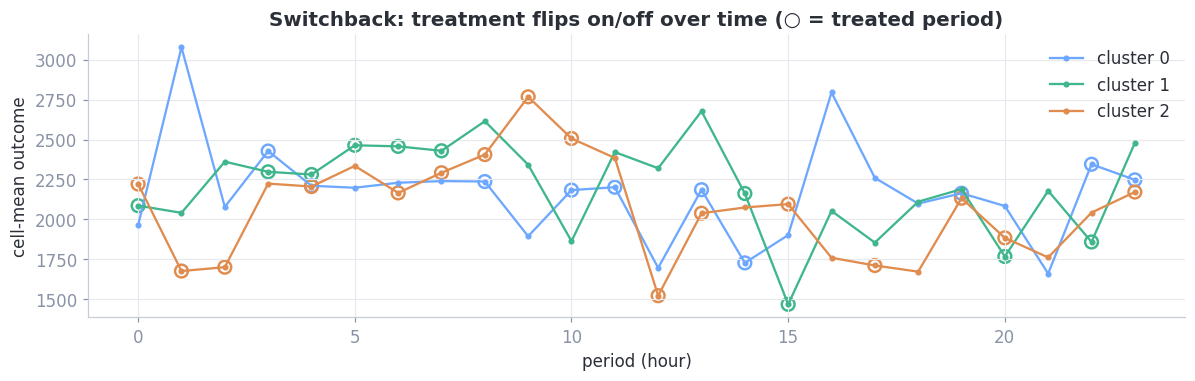

In [3]:
cellmean = df.groupby(["cluster", "period"]).agg(y=("y", "mean"), treat=("treat", "first")).reset_index()
fig, ax = plt.subplots(figsize=(11, 3.6))
for j, c in zip([0, 1, 2], [CUPED, CUPAC, DML]):
    sub = cellmean[cellmean.cluster == j]
    ax.plot(sub.period, sub.y, "-o", ms=3, color=c, label=f"cluster {j}")
    on = sub[sub.treat == 1]
    ax.scatter(on.period, on.y, s=70, facecolors="none", edgecolors=c, linewidths=1.6)
ax.set_xlabel("period (hour)"); ax.set_ylabel("cell-mean outcome")
ax.set_title("Switchback: treatment flips on/off over time (○ = treated period)"); ax.legend()
plt.tight_layout(); plt.show()

## 3. The four estimators

All estimate the same ATE $\tau$; they differ in how much **variance** they remove. We use
**cluster-robust SEs** (clustered on `cluster`) throughout — the design correlates outcomes within a
cluster, so naive i.i.d. SEs would lie.

In [4]:
def _cluster_se_of_mean(values, clusters):
    """Cluster-robust SE of a sample mean (sandwich): clusters are the independent units."""
    v = np.asarray(values); n = v.size; mbar = v.mean()
    s = pd.Series(v - mbar).groupby(np.asarray(clusters)).sum().to_numpy()
    return np.sqrt((s ** 2).sum()) / n


def est_raw(df):
    m = smf.ols("y ~ treat", df).fit(cov_type="cluster", cov_kwds={"groups": df.cluster})
    return m.params["treat"], m.bse["treat"]


def cuped_adjust(y, x):
    x = np.asarray(x, float); y = np.asarray(y, float)
    theta = np.cov(y, x, ddof=1)[0, 1] / x.var(ddof=1)
    return y - theta * (x - x.mean())


def est_cuped(df, x):
    d = df.assign(yc=cuped_adjust(df.y.values, x))
    m = smf.ols("yc ~ treat", d).fit(cov_type="cluster", cov_kwds={"groups": d.cluster})
    return m.params["treat"], m.bse["treat"]


def _oof(df, feature_cols, target="y", mask=None, seed=0):
    """Cross-fitted (out-of-fold) predictions of `target` from features — no leakage."""
    X = df[feature_cols].to_numpy(float); y = df[target].to_numpy(float)
    pred = np.zeros(len(df))
    for tr, te in KFold(2, shuffle=True, random_state=seed).split(X):
        idx = tr if mask is None else tr[mask[tr]]
        model = HistGradientBoostingRegressor(max_depth=3, max_iter=120, learning_rate=0.12)
        model.fit(X[idx], y[idx])
        pred[te] = model.predict(X[te])
    return pred


def est_cupac(df, feature_cols, seed=0):
    """CUPAC: use a cross-fitted ML prediction of the outcome as the CUPED covariate."""
    ghat = _oof(df, feature_cols, "y", seed=seed)
    return est_cuped(df, ghat)


def est_dml_dr(df, feature_cols, e=0.5, seed=0):
    """Doubly-robust AIPW with cross-fitted per-arm outcome models and known propensity e=0.5."""
    X = df[feature_cols].to_numpy(float); y = df.y.to_numpy(float); t = df.treat.to_numpy()
    mu1 = np.zeros(len(df)); mu0 = np.zeros(len(df))
    for tr, te in KFold(2, shuffle=True, random_state=seed).split(X):
        for arm, mu in ((1, mu1), (0, mu0)):
            sel = tr[t[tr] == arm]
            m = HistGradientBoostingRegressor(max_depth=3, max_iter=120, learning_rate=0.12)
            m.fit(X[sel], y[sel]); mu[te] = m.predict(X[te])
    score = mu1 - mu0 + t / e * (y - mu1) - (1 - t) / (1 - e) * (y - mu0)
    return float(score.mean()), _cluster_se_of_mean(score, df.cluster.values)


def add_covariate(df, r2=0.6, target="macro", seed=7):
    """A synthetic covariate correlated with `target` (macro or resid) at the requested R² — used in
    §5 to show that targeting the *macro* share crushes far more variance than targeting residual."""
    rng = np.random.default_rng(seed)
    z = df[target].to_numpy(float)
    zc = (z - z.mean()) / (z.std() + 1e-12)
    x = np.sqrt(r2) * zc + np.sqrt(1 - r2) * rng.standard_normal(len(df))
    return df.assign(x=x)

**The covariates** are all *pre-treatment* (so they can't bias the effect):
- **CUPED** adjusts *linearly* on the **historical baseline** `x_hist` (last week's α+γ for the
  cell) — the classic single-covariate move.
- **CUPAC** feeds `[x_hist, z, period]` to a gradient-boosted model, so on top of the baseline it
  captures the **nonlinear** $\alpha(z)$ and the diurnal $\gamma$ that the linear term can't.
- **DML-DR** uses the same model inside an AIPW score (robust to a wrong model).

That extra structure is exactly why ML-based VR beats linear adjustment in switchbacks.

In [5]:
feat = ["x_hist", "z", "period"]
truth = 20.0
for name, fn in [("Raw", lambda: est_raw(df)), ("CUPED", lambda: est_cuped(df, df.x_hist.values)),
                 ("CUPAC", lambda: est_cupac(df, feat)), ("DML-DR", lambda: est_dml_dr(df, feat))]:
    pt, se = fn()
    print(f"  {name:<7} tau_hat = {pt:7.2f}   SE = {se:6.2f}   (truth tau = {truth})")

  Raw     tau_hat =    1.32   SE =  21.82   (truth tau = 20.0)
  CUPED   tau_hat =    1.79   SE =  18.03   (truth tau = 20.0)


  CUPAC   tau_hat =    5.69   SE =  15.74   (truth tau = 20.0)


  DML-DR  tau_hat =    4.88   SE =  15.85   (truth tau = 20.0)


## 4. The headline result — how much power does VR buy?

Run the experiment many times (Monte-Carlo) and measure, for each estimator: the **SE ratio** vs Raw,
the **variance reduction %** ($1-\text{SE ratio}^2$), and the **power** to detect τ at α=5%. This is
the poster's headline table (qualitatively — we use a smaller, faster sim).

In [6]:
def one_run(seed, **kw):
    d = simulate_switchback(seed=seed, **kw)
    out = {}
    for name, fn in [("Raw", lambda: est_raw(d)), ("CUPED", lambda: est_cuped(d, d.x_hist.values)),
                     ("CUPAC", lambda: est_cupac(d, feat, seed=seed)),
                     ("DML-DR", lambda: est_dml_dr(d, feat, seed=seed))]:
        pt, se = fn(); out[name] = (pt, se)
    return out

# baseline regime: cv=1.5 cluster-size imbalance (the poster's baseline) — macro shocks are amplified,
# so variance reduction has a large, high-leverage target.
REPS = 60
runs = [one_run(s, cv=1.5) for s in range(REPS)]
names = ["Raw", "CUPED", "CUPAC", "DML-DR"]
rows = []
for nm in names:
    pts = np.array([r[nm][0] for r in runs]); ses = np.array([r[nm][1] for r in runs])
    se_emp = pts.std(ddof=1)                                   # empirical SE = sd of the estimate
    power = np.mean(np.abs(pts) / ses > 1.959964)              # reject H0: τ=0 at 5%
    rows.append({"estimator": nm, "SE": se_emp, "power": power, "mean_se": ses.mean(), "bias": pts.mean() - 20})
tab = pd.DataFrame(rows)
tab["SE_ratio"] = tab.SE / tab.SE.iloc[0]
tab["VR_%"] = (1 - tab.SE_ratio ** 2) * 100
print(tab[["estimator", "SE_ratio", "VR_%", "power", "bias"]].round({"SE_ratio": 3, "VR_%": 0, "power": 2, "bias": 2}).to_string(index=False))

estimator  SE_ratio  VR_%  power  bias
      Raw     1.000   0.0   0.08 -3.79
    CUPED     0.743  45.0   0.18 -0.81
    CUPAC     0.573  67.0   0.25 -1.39
   DML-DR     0.628  61.0   0.23  1.25


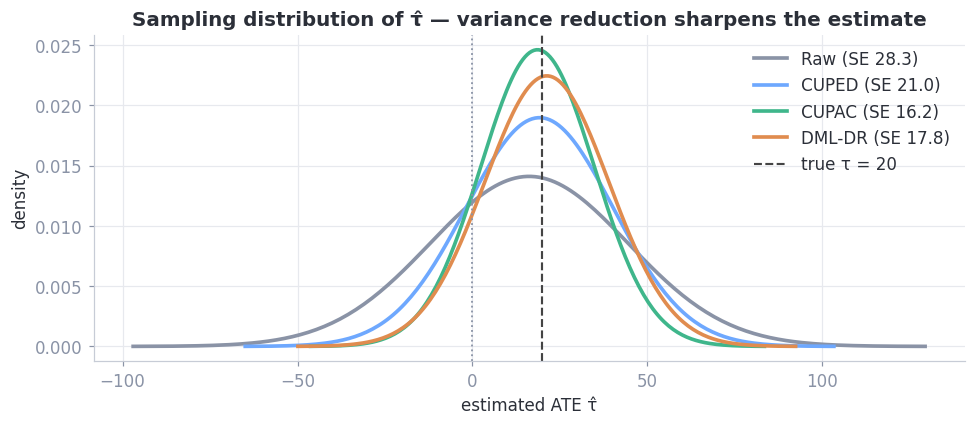

In [7]:
# the "ATE density" picture from the poster — tighter distributions = more power
fig, ax = plt.subplots(figsize=(9, 4))
for nm in names:
    pts = np.array([r[nm][0] for r in runs])
    xs = np.linspace(pts.mean() - 4 * pts.std(), pts.mean() + 4 * pts.std(), 200)
    dens = np.exp(-0.5 * ((xs - pts.mean()) / pts.std()) ** 2) / (pts.std() * np.sqrt(2 * np.pi))
    ax.plot(xs, dens, color=COL[nm], lw=2.4, label=f"{nm} (SE {pts.std():.1f})")
ax.axvline(20, color="#444", ls="--", lw=1.4, label="true τ = 20")
ax.axvline(0, color=RAW, ls=":", lw=1.2)
ax.set_xlabel("estimated ATE τ̂"); ax.set_ylabel("density")
ax.set_title("Sampling distribution of τ̂ — variance reduction sharpens the estimate"); ax.legend()
plt.tight_layout(); plt.show()

Raw is wide (often can't separate τ=20 from 0); each VR step concentrates the distribution around the
truth → more power, smaller detectable effect (MDE). **All stay unbiased** (centred on τ=20) because
the covariate is pre-treatment. That's the whole pitch: *free* power.

## 5. Power & the structural floor (Pankratev's formula)

The closed-form asymptotic variance of the individual-level estimator:

$$\operatorname{Var}(\hat\tau)\approx\frac{4\sigma^2_{total}}{J\,H}\Big[\frac{S_{res}}{\bar n}
  + S_{macro}\big(\tfrac1{\bar n}+1+cv^2\big)\Big].$$

The residual term is $\propto 1/\bar n$ (averages away with density); the **macro term has a $+1$ that
never vanishes** — a *structural floor*. Adding observations *within* cells hits rapidly diminishing
returns; you need more **cells** ($J\!\cdot\!H$) or a smaller **macro share**.

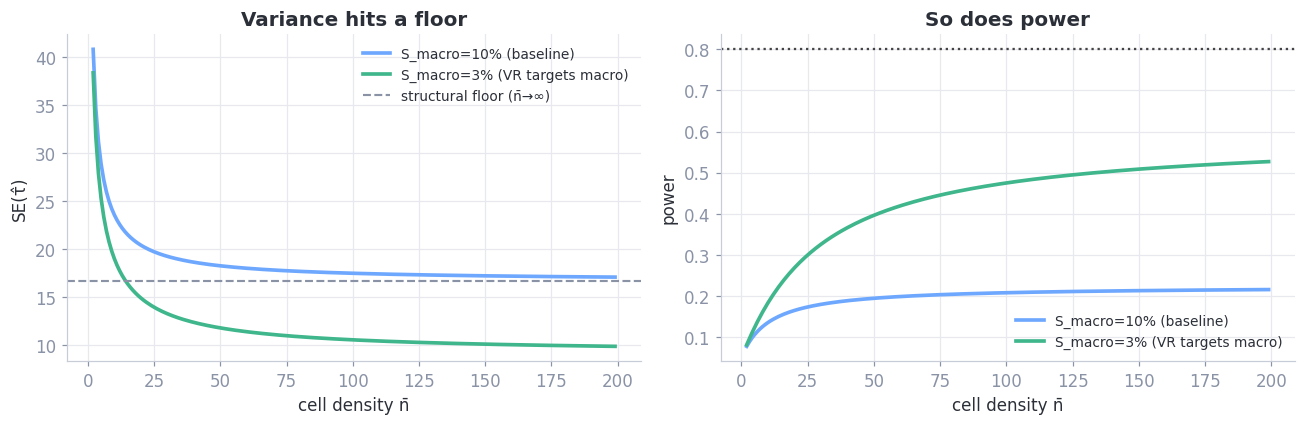

In [8]:
def var_formula(J=60, H=24, n_bar=15, sigma_total=1000.0, S_res=0.90, S_macro=0.10, cv=0.0):
    return 4 * sigma_total ** 2 / (J * H) * (S_res / n_bar + S_macro * (1 / n_bar + 1 + cv ** 2))

def power_from_var(var, tau=20.0, alpha=0.05):
    from scipy.stats import norm
    z = tau / np.sqrt(var)
    return norm.cdf(z - norm.ppf(1 - alpha / 2)) + norm.cdf(-z - norm.ppf(1 - alpha / 2))

n_grid = np.arange(2, 200)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for sm, c, lab in [(0.10, CUPED, "S_macro=10% (baseline)"), (0.03, CUPAC, "S_macro=3% (VR targets macro)")]:
    se = np.sqrt([var_formula(n_bar=n, S_res=1 - sm, S_macro=sm) for n in n_grid])
    ax[0].plot(n_grid, se, color=c, lw=2.4, label=lab)
    ax[1].plot(n_grid, [power_from_var(var_formula(n_bar=n, S_res=1 - sm, S_macro=sm)) for n in n_grid],
               color=c, lw=2.4, label=lab)
floor = np.sqrt(var_formula(n_bar=1e9, S_res=0.90, S_macro=0.10))
ax[0].axhline(floor, color=RAW, ls="--", lw=1.4, label="structural floor (n̄→∞)")
ax[0].set_xlabel("cell density n̄"); ax[0].set_ylabel("SE(τ̂)"); ax[0].set_title("Variance hits a floor"); ax[0].legend(fontsize=9)
ax[1].set_xlabel("cell density n̄"); ax[1].set_ylabel("power"); ax[1].set_title("So does power"); ax[1].axhline(0.8, color="#444", ls=":"); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

Packing more units into a cell (moving right) helps for a while, then **flattens** — the floor.
Lowering the *macro* share (green: a CUPAC that predicts macro shocks) moves the **whole floor down**,
which is why variance reduction beats brute-force density. Now the punchline:

### The structural inversion — target *macro*, not residual

Raw variance is 90% residual, 10% macro, so a naive instinct says "predict the residual." But the
residual is already crushed by $1/\bar n$, while macro is amplified by $1+cv^2$. We test it directly:
build two covariates of equal strength — one predicting **macro**, one predicting **residual** — and
CUPED-adjust with each.

In [9]:
def cuped_se(target, reps=40):
    """Empirical SE of CUPED using a covariate (R²=0.6) that predicts `target` (macro or resid)."""
    pts = []
    for s in range(reps):
        d = add_covariate(simulate_switchback(seed=s, cv=1.5), r2=0.6, target=target)
        pts.append(est_cuped(d, d.x.values)[0])
    return float(np.std(pts, ddof=1))

raw_se = float(np.std([est_raw(simulate_switchback(seed=s, cv=1.5))[0] for s in range(40)], ddof=1))
se_macro, se_resid = cuped_se("macro"), cuped_se("resid")
print(f"Raw SE                          : {raw_se:6.2f}")
print(f"CUPED targeting MACRO    (R2=.6): {se_macro:6.2f}   VR {1-(se_macro/raw_se)**2:5.1%}")
print(f"CUPED targeting RESIDUAL (R2=.6): {se_resid:6.2f}   VR {1-(se_resid/raw_se)**2:5.1%}")
print("-> same covariate strength, but targeting the (small) macro share crushes far more variance.")

Raw SE                          :  22.93
CUPED targeting MACRO    (R2=.6):  14.85   VR 58.1%
CUPED targeting RESIDUAL (R2=.6):  20.88   VR 17.1%
-> same covariate strength, but targeting the (small) macro share crushes far more variance.


## 6. The challenges (why switchbacks are genuinely hard)

### 6.1 Cluster-size imbalance — the $(1+cv^2)$ penalty
Real markets have a few huge zones and many tiny ones. Macro variance is *amplified* by $cv^2$
(a modern Moulton factor). Power collapses as imbalance grows; VR that shrinks macro variance
(CUPAC/DML) holds up better than Raw/CUPED.

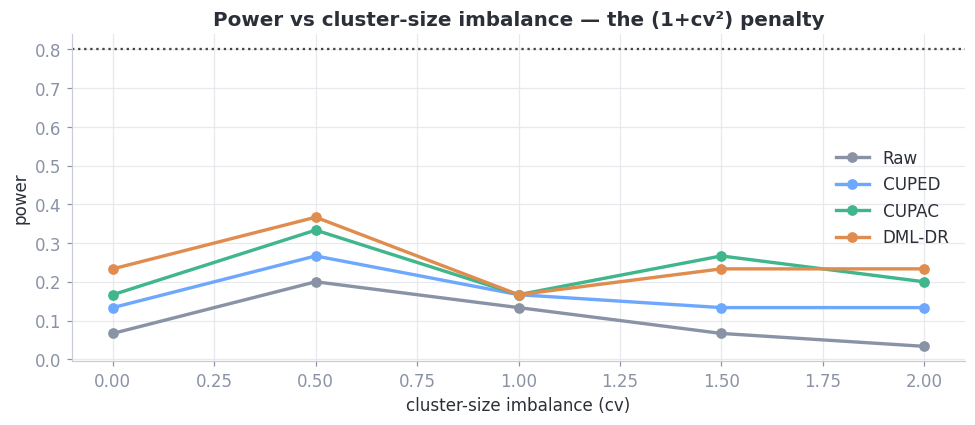

In [10]:
cvs = [0.0, 0.5, 1.0, 1.5, 2.0]
pow_by = {nm: [] for nm in names}
for cv in cvs:
    runs_cv = [one_run(s, cv=cv) for s in range(30)]
    for nm in names:
        pts = np.array([r[nm][0] for r in runs_cv]); ses = np.array([r[nm][1] for r in runs_cv])
        pow_by[nm].append(np.mean(np.abs(pts) / ses > 1.959964))
fig, ax = plt.subplots(figsize=(9, 4))
for nm in names:
    ax.plot(cvs, pow_by[nm], "-o", color=COL[nm], lw=2.2, label=nm)
ax.set_xlabel("cluster-size imbalance (cv)"); ax.set_ylabel("power"); ax.axhline(0.8, color="#444", ls=":")
ax.set_title("Power vs cluster-size imbalance — the (1+cv²) penalty"); ax.legend()
plt.tight_layout(); plt.show()

### 6.2 Carryover & the efficiency–robustness trap (Type-S errors)
Carryover (a treatment persisting after switch-off) **biases all estimators about equally** — it's a
property of the *data*, not the estimator. The danger is subtler: VR shrinks the CI around the
*biased* point, so an aggressive estimator becomes **confidently wrong**. Under **sign-flip**
carryover (treatment helps now but hurts later), the bias can flip the sign → **Type-S errors**
(significant in the *wrong* direction). We measure the wrong-sign rejection rate vs carryover intensity.

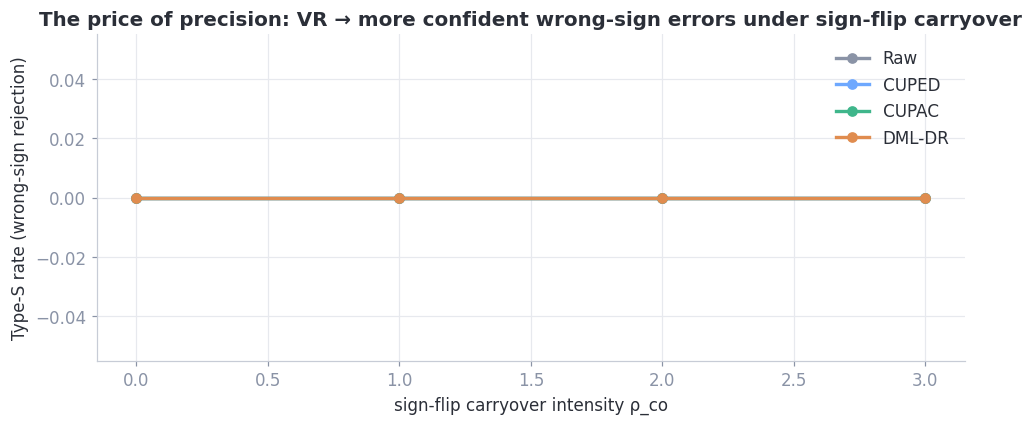

In [11]:
def type_s_rate(carry, signflip, reps=40):
    out = {nm: 0 for nm in names}
    for s in range(reps):
        d = simulate_switchback(seed=s, carry=carry, carry_signflip=signflip)
        for nm, fn in [("Raw", lambda: est_raw(d)), ("CUPED", lambda: est_cuped(d, d.x_hist.values)),
                       ("CUPAC", lambda: est_cupac(d, feat, seed=s)), ("DML-DR", lambda: est_dml_dr(d, feat, seed=s))]:
            pt, se = fn()
            if abs(pt) / se > 1.959964 and pt < 0:   # significant AND wrong sign (truth τ=+20)
                out[nm] += 1
    return {nm: out[nm] / reps for nm in names}

carries = [0.0, 1.0, 2.0, 3.0]
ts = {nm: [] for nm in names}
for c in carries:
    r = type_s_rate(c, signflip=True)
    for nm in names: ts[nm].append(r[nm])
fig, ax = plt.subplots(figsize=(9, 4))
for nm in names:
    ax.plot(carries, ts[nm], "-o", color=COL[nm], lw=2.2, label=nm)
ax.set_xlabel("sign-flip carryover intensity ρ_co"); ax.set_ylabel("Type-S rate (wrong-sign rejection)")
ax.set_title("The price of precision: VR → more confident wrong-sign errors under sign-flip carryover")
ax.legend(); plt.tight_layout(); plt.show()

As carryover grows, the bias drags the estimate negative; the **tighter** an estimator's CI, the more
often it crosses zero into a *significant wrong-sign* result. DML-DR/CUPAC (most precise) suffer most —
**efficiency bought fragility** (Hampel et al. 1986). Raw, being imprecise, "fails safe" by staying
inconclusive. This is the central robustness caveat of design-aware VR.

## 7. Recommendations (the poster's verdict)

| scenario | recommended | avoid |
|---|---|---|
| SUTVA holds, many clusters ($n_{cl}\ge 50$) | **DML-DR / CUPAC** | — |
| small experiment ($n_{cl}<50$) | **CUPAC** | DML-DR (propensity overfits) |
| mild (attenuating) interference | DML-DR / CUPAC | — |
| **severe sign-flip interference** | **Raw** | DML-DR |
| no ML infrastructure | **CUPED** | — |

> **Goldilocks:** **CUPAC captures ~85% of DML-DR's efficiency gains with robust CI calibration** and
> no propensity-overfitting → the default for switchbacks where SUTVA can't be guaranteed.

**What you learned, practically:**
1. A switchback trades cross-sectional interference for temporal problems (carryover, autocorrelation).
2. Power has a **structural floor** from macro shocks $\times(1+cv^2)$ — density alone can't fix it.
3. VR (CUPED→CUPAC→DML-DR) buys power for free *only* by targeting the **macro** share, not residual.
4. The same precision that buys power makes you **fragile** to carryover (Type-S) — efficiency vs robustness.

Companion reading: `paper-library/papers/switchback-and-variance-reduction.md` and the source papers
(Bojinov 2021; Pankratev 2026 ×2; Deng 2013 CUPED; Chernozhukov 2018 DML).